In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
os.chdir('/home/jovyan/sdseSp26/final project')

In [2]:
# import data
data = pd.read_csv('resources/housing.csv')

In [3]:
# clean data just in case by dropping rows with no data
#clean_data = data[data["median_house_value"] < 500000].dropna(axis=0, how='any')
clean_data = data.dropna(axis=0, how='any').copy()
clean_features = clean_data.drop(columns=['median_house_value']).columns
#print(clean_features)

In [4]:
# make the data make more sense by adding ratios 
# try to get average house size on the block by getting rooms/house
#clean_data['rooms_per_household'] = clean_data['total_rooms'] / clean_data['households']
# try to determine if homes are bedroom heavy - could indicate housing density
#clean_data['bedrooms_to_room_ratio'] = clean_data['total_bedrooms'] / clean_data['total_rooms']
# try to figure out household size - could capture crowding
#clean_data['population_per_household'] = clean_data['population'] / clean_data['households']
# try to get rooms per person to indicate how much space each person gets
#clean_data['rooms_per_person'] = clean_data['total_rooms'] / clean_data['population']
# try to get bedrooms per person to indicate crowding / density
#clean_data['bedrooms_per_person'] = clean_data['total_bedrooms'] / clean_data['population']

In [5]:
# separate features (X) from target (y = price)
#X = clean_data.drop(columns=['median_house_value']).values
#y = clean_data['median_house_value'].values

In [6]:
def split_data(df, pt, pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    #shuffle data
    df = df.sample(frac=1, random_state=2434).reset_index(drop=True)

    N = len(df) # numnber of samples in raw_data
    data_train = df.copy().iloc[0:int(N*pt)]
    data_validate = df.copy().iloc[int(N*pt):int(N*pt+N*pv)]
    data_test = df.copy().iloc[(int(N*pt+N*pv)):]
    
    return data_train, data_validate, data_test

In [7]:
data_train, data_validate, data_test = split_data(clean_data,pt=0.7,pv=0.15)

In [8]:
# split data into training and testing sets
#from sklearn.model_selection import train_test_split
#Xtrain, Xtest, ytrain, ytest = train_test_split(X,
#                                                y,
#                                                test_size=0.2, # 20% for testing
#                                                random_state=42 )

In [9]:
# encode columns with strings ('ocean_proximity') and separate X and y
Xtrain = pd.get_dummies(data_train.drop(columns=['median_house_value']))
ytrain = data_train['median_house_value'].values
ytrain_log = np.log1p(data_train['median_house_value'].values)

Xvalidate = pd.get_dummies(data_validate.drop(columns=['median_house_value']))
yvalidate = data_validate['median_house_value'].values
yvalidate_log = np.log1p(data_validate['median_house_value'].values)

Xtest = pd.get_dummies(data_test.drop(columns=['median_house_value']))
ytest = data_test['median_house_value'].values
ytest_log = np.log1p(data_test['median_house_value'].values)

# reindex the encoding to match training data
Xvalidate = Xvalidate.reindex(columns=Xtrain.columns, fill_value=0)
Xtest = Xtest.reindex(columns=Xtrain.columns, fill_value=0)

In [10]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Use the fit_transform method to perform the normalization of columns
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xvalidate_scaled = scaler.transform(Xvalidate)
Xtest_scaled = scaler.transform(Xtest)

# Format the normalized input as a DataFrame
# Xtrain_norm = pd.DataFrame(X, index=Xtrain_scaled.index, columns=Xtrain.columns) 

In [11]:
#%pip install --upgrade pip
#%pip install --extra-index-url https://download.pytorch.org/whl/cpu torch

In [12]:
# import modules for neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [13]:
# Build an MLP
random.seed(2434)  
np.random.seed(2434)
torch.manual_seed(2434)

D = Xtrain_scaled.shape[1]

model_mlp = nn.Sequential(
    nn.Linear(D, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

for layer in model_mlp:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

random.seed(2434)  
np.random.seed(2434)
torch.manual_seed(2434)

model_mlp_log = nn.Sequential(
    nn.Linear(D, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.Tanh(),
    nn.Linear(64, 32),
    nn.Tanh(),
    nn.Linear(32, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

for layer in model_mlp_log:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

In [14]:
# convert to tensors
Xtrain_t = torch.tensor(Xtrain_scaled, dtype=torch.float32)
ytrain_t = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1)
ytrain_log_t = torch.tensor(ytrain_log, dtype=torch.float32).reshape(-1,1)

Xvalidate_t = torch.tensor(Xvalidate_scaled, dtype=torch.float32)
yvalidate_t = torch.tensor(yvalidate, dtype=torch.float32).reshape(-1,1)
yvalidate_log_t = torch.tensor(yvalidate_log, dtype=torch.float32).reshape(-1,1)

Xtest_t = torch.tensor(Xtest_scaled, dtype=torch.float32)
ytest_t = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1)
ytest_log_t = torch.tensor(ytest_log, dtype=torch.float32).reshape(-1,1)

train_loader = DataLoader(
    TensorDataset(Xtrain_t, ytrain_t),
    batch_size=16,
    shuffle=True
)

train_loader_log = DataLoader(
    TensorDataset(Xtrain_t, ytrain_log_t),
    batch_size=32,
    shuffle=True
)

In [15]:
def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

In [16]:
# Use model_mlp

best_val_mae = float("inf")
best_state = None

loss_fn_mlp = nn.MSELoss()
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=0.0001, weight_decay=1e-6)
history_mlp = {"epoch": [], "mae": [], "val_mae": []}

for epoch in range(150):
    model_mlp.train()
    for xb, yb in train_loader:
        optimizer_mlp.zero_grad()
        yhat_train = model_mlp(xb)
        loss = loss_fn_mlp(yhat_train, yb)
        loss.backward()
        optimizer_mlp.step()

    model_mlp.eval()
    with torch.no_grad():
        train_pred = model_mlp(Xtrain_t).cpu().numpy().reshape(-1)
        val_pred_epoch = model_mlp(Xvalidate_t).cpu().numpy().reshape(-1)

    train_mae = mean_absolute_error(ytrain, train_pred)
    val_mae = mean_absolute_error(yvalidate, val_pred_epoch)

    history_mlp["epoch"].append(epoch)
    history_mlp["mae"].append(mean_absolute_error(ytrain, train_pred))
    history_mlp["val_mae"].append(mean_absolute_error(yvalidate, val_pred_epoch))

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}

#print('Validation: ', assess(Xvalidate[:,-1], yvalidate, predict_model(model_mlp, Xvalidate_scaled)))

model_mlp.load_state_dict(best_state)

val_pred_final = predict_model(model_mlp, Xvalidate_scaled)
mae_val = mean_absolute_error(yvalidate, val_pred_final)
r2_val = r2_score(yvalidate, val_pred_final)
print("validation MAE: ", mae_val)
print("validation R2: ", r2_val)


validation MAE:  44604.109413234095
validation R2:  0.6999546221144282


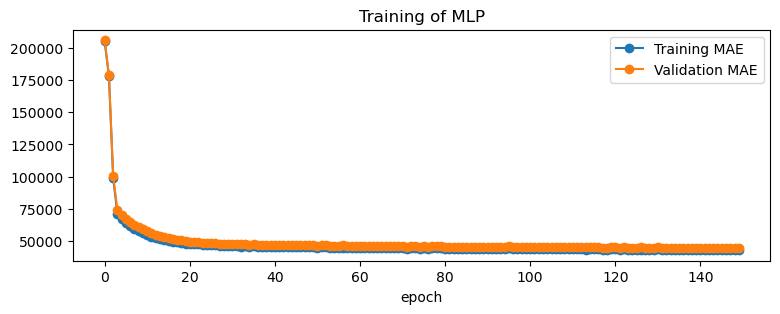

In [17]:
# plot training history
num_epochs = len(history_mlp['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(num_epochs), history_mlp['mae'], marker='o', label='Training MAE')
plt.plot(range(num_epochs), history_mlp['val_mae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of MLP')
plt.legend();

In [16]:
best_val_mae_log = float("inf")
best_state_log = None

loss_fn_mlp_log = nn.MSELoss()
optimizer_mlp_log = torch.optim.Adam(model_mlp_log.parameters(), lr=0.001, weight_decay=1e-5)
history_mlp_log = {"epoch": [], "mae": [], "val_mae": []}

for epoch in range(150):
    model_mlp_log.train()
    for xb, yb in train_loader_log:
        optimizer_mlp_log.zero_grad()
        yhat_train = model_mlp_log(xb)
        loss = loss_fn_mlp_log(yhat_train, yb)
        loss.backward()
        optimizer_mlp_log.step()

    model_mlp_log.eval()
    with torch.no_grad():
        train_pred_log = model_mlp_log(Xtrain_t).cpu().numpy().reshape(-1)
        val_pred_epoch_log = model_mlp_log(Xvalidate_t).cpu().numpy().reshape(-1)
    
   # train_pred = np.expm1(train_pred_log)
    train_pred = np.expm1(np.clip(train_pred_log, -20, 20))
    #val_pred_epoch = np.expm1(val_pred_epoch_log)
    val_pred_epoch = np.expm1(np.clip(val_pred_epoch_log, -20, 20))

    train_mae = mean_absolute_error(ytrain, train_pred)
    val_mae = mean_absolute_error(yvalidate, val_pred_epoch)

    history_mlp_log["epoch"].append(epoch)
    history_mlp_log["mae"].append(mean_absolute_error(ytrain, train_pred))
    history_mlp_log["val_mae"].append(mean_absolute_error(yvalidate, val_pred_epoch))

    if val_mae < best_val_mae_log:
        best_val_mae_log = val_mae
        best_state_log = {k: v.clone() for k, v in model_mlp_log.state_dict().items()}

model_mlp_log.load_state_dict(best_state_log)

val_pred_log = predict_model(model_mlp_log, Xvalidate_scaled)
val_pred_log_final = np.expm1(val_pred_log)
yvalidate_actual = yvalidate
mae_log = mean_absolute_error(yvalidate_actual, val_pred_log_final)
r2_log = r2_score(yvalidate_actual, val_pred_log_final)

from sklearn.metrics import mean_squared_error

rmse_val = np.sqrt(mean_squared_error(yvalidate, val_pred_log_final))

print("validation MAE: ", mae_log)
print("validation R2: ", r2_log)
print("Validation RMSE:", rmse_val)

validation MAE:  32801.38962454119
validation R2:  0.8060781020614542
Validation RMSE: 51372.153634662376


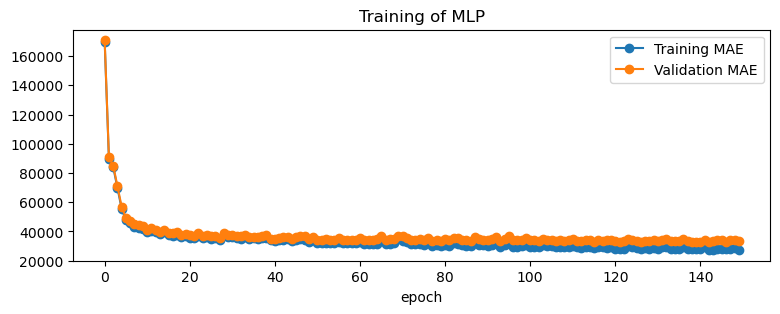

In [17]:
# plot training history
num_epochs = len(history_mlp_log['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(num_epochs), history_mlp_log['mae'], marker='o', label='Training MAE')
plt.plot(range(num_epochs), history_mlp_log['val_mae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of MLP')
plt.legend();

In [18]:
print(train_pred_log.min(), train_pred_log.max())

10.05242 13.122538


In [19]:
best_epoch = np.argmin(history_mlp_log["val_mae"])
print("Best epoch:", best_epoch)
print("Best val MAE:", history_mlp_log["val_mae"][best_epoch])

Best epoch: 139
Best val MAE: 32801.38962454119


In [20]:
mean_price_val = np.mean(yvalidate)
percent_error_val = mae_log / mean_price_val
print("val Percent Error:", percent_error_val)

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(yvalidate, val_pred_log_final)
print("MAPE:", mape)

val Percent Error: 0.15845860810727722
MAPE: 0.17657152015749192


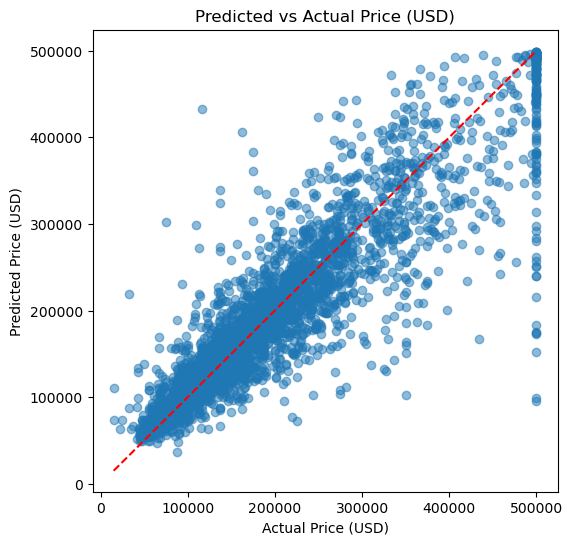

In [21]:
# plot actual vs predicted price for validation set
plt.figure(figsize=(6,6))
plt.scatter(yvalidate, val_pred_log_final, alpha=0.5)

# perfect prediction line
plt.plot([yvalidate.min(), yvalidate.max()],
         [yvalidate.min(), yvalidate.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Predicted vs Actual Price (USD)")
plt.show()

In [17]:
class TorchModelWrapper:
    def __init__(self, model, log_target=False):
        self.model = model
        self.log_target = log_target
        
    def fit(self, X, y=None):
        return self
        
    def predict(self, X):
        preds = predict_model(self.model, X).reshape(-1)
        if self.log_target:
            preds = np.expm1(preds)
        return preds

In [18]:
from sklearn.inspection import permutation_importance
import pandas as pd

wrapped_model_log_val = TorchModelWrapper(model_mlp_log, log_target=True)  # or model_mlp

result = permutation_importance(
    wrapped_model_log_val,
    Xvalidate_scaled,
    yvalidate,
    n_repeats=5,
    random_state=2434,
    scoring="neg_mean_absolute_error"
)

In [24]:
importance_val = pd.DataFrame({
    "Feature": Xtrain.columns,
    "Importance": result.importances_mean
})

def group_feature(name):
    if name.startswith("ocean_proximity_"):
        return "ocean_proximity"
    else:
        return name

importance_val["Grouped"] = importance_val["Feature"].apply(group_feature)

grouped_importance_val = (
    importance_val
    .groupby("Grouped")["Importance"]
    .sum()
    .reset_index()
    .sort_values("Importance", ascending=False)
)

#importance = importance.sort_values("Importance", ascending=False)
print("\nTop 10 features by permutation importance:")
print(grouped_importance_val.head(10))


Top 10 features by permutation importance:
              Grouped    Importance
2            latitude  49816.454208
3           longitude  47200.637878
8         total_rooms  31350.457947
4       median_income  30895.770198
6          population  29069.177546
5     ocean_proximity  26882.381144
0          households  22147.194981
7      total_bedrooms  16272.000064
1  housing_median_age   6358.357399


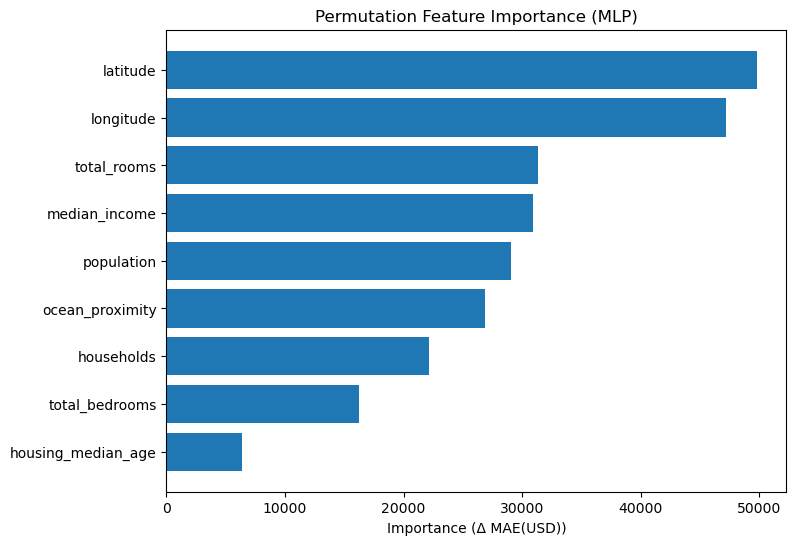

In [25]:
import matplotlib.pyplot as plt

top_val = grouped_importance_val.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_val["Grouped"], top_val["Importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (MLP)")
plt.xlabel("Importance (Δ MAE(USD))")
plt.show()

In [19]:
test_pred_log = predict_model(model_mlp_log, Xtest_scaled)
test_pred = np.expm1(test_pred_log)
mae_test = mean_absolute_error(ytest, test_pred)
r2_test = r2_score(ytest, test_pred)

rmse_test = np.sqrt(mean_squared_error(ytest, test_pred))

print("Test MAE: ", mae_test)
print("Test R2: ", r2_test)
print("Test RMSE:", rmse_test)

mean_price_test = np.mean(ytest)
percent_error_test = mae_test / mean_price_test
print("test Percent Error:", percent_error_test)

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(ytest, test_pred)
print("MAPE:", mape)

Test MAE:  33280.20333528752
Test R2:  0.8004603818126301
Test RMSE: 51640.25820538064
test Percent Error: 0.15791431033118525
MAPE: 0.16931312637803284


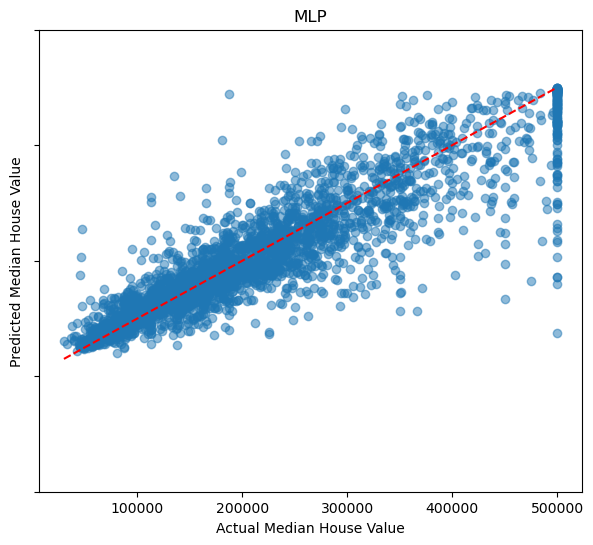

In [29]:
# plot actual vs predicted price for test set
plt.figure(figsize=(7,6))
plt.scatter(ytest, test_pred, alpha=0.5)

# perfect prediction line
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("MLP")

# set y-axis ticks and limits
plt.ylim(-200000, 600000)
ticks = range(-200000, 600001, 200000)
plt.yticks(ticks, [''] * len(ticks))  # keep ticks, remove labels

plt.show()

In [31]:
wrapped_model_log_test = TorchModelWrapper(model_mlp_log, log_target=True)  # or model_mlp

result = permutation_importance(
    wrapped_model_log_test,
    Xvalidate_scaled,
    yvalidate,
    n_repeats=5,
    random_state=2434,
    scoring="neg_root_mean_squared_error"
)

In [32]:
importance_test = pd.DataFrame({
    "Feature": Xtrain.columns,
    "Importance": result.importances_mean
})

def group_feature(name):
    if name.startswith("ocean_proximity_"):
        return "ocean_proximity"
    else:
        return name

importance_test["Grouped"] = importance_test["Feature"].apply(group_feature)

grouped_importance_test = (
    importance_test
    .groupby("Grouped")["Importance"]
    .sum()
    .reset_index()
    .sort_values("Importance", ascending=False)
)

#importance = importance.sort_values("Importance", ascending=False)
print("\nTop 10 features by permutation importance:")
print(grouped_importance_test.head(15))


Top 10 features by permutation importance:
              Grouped    Importance
2            latitude  64526.301046
3           longitude  61650.884813
4       median_income  43003.390153
8         total_rooms  40418.249632
5     ocean_proximity  38633.314418
6          population  37823.398968
0          households  29912.999701
7      total_bedrooms  22084.269817
1  housing_median_age   8555.984632


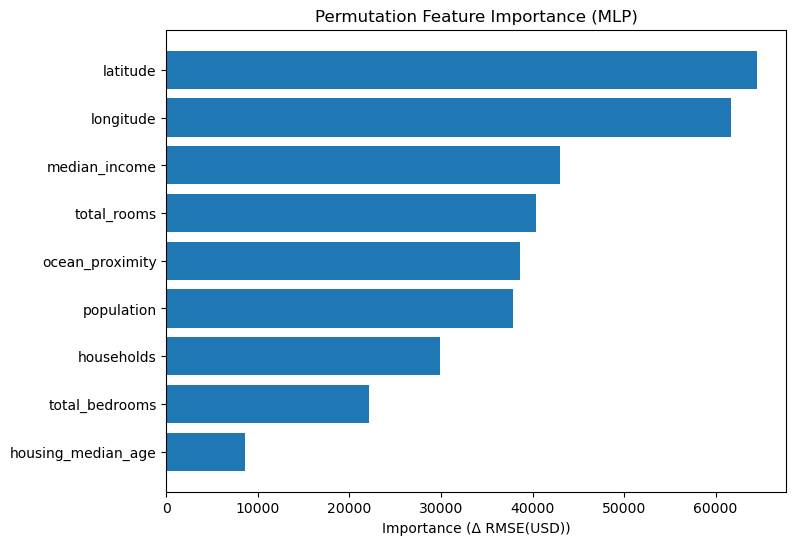

In [33]:
import matplotlib.pyplot as plt

top_test = grouped_importance_test.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_test["Grouped"], top_test["Importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (MLP)")
plt.xlabel("Importance (Δ RMSE(USD))")
plt.show()